In [1]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm


In [2]:
# results in FASTA form into dataframe

def pfam_results(results_input):
    data = {'accession': [], 'taxon': [], 'seq identifier': [], 'I Helix': []}
    with open(results_input) as fp:
        for record in SeqIO.parse(fp, "fasta"):
            seqident = re.findall(r"\|(?P<sequence_id>\w+)\|", record.id)
            accession = record.description
            taxon = re.findall(r"OX=(\d+)", record.description)
            sequence = str(record.seq)

            # attaching to dictionary
            data['seq identifier'].append(", ".join(seqident))
            data['accession'].append(accession)
            data['taxon'].append(", ".join(taxon))
            data['I Helix'].append(sequence)

    df = pd.DataFrame.from_dict(data)
    return df

In [ ]:
# Converting HMM search output for pfam data to FASTA file
input = '/home/alecia/chapter3-repo/output/hmm_search_3/pfam/3/ihelixhits_e_0p001_z__T_.aln'
outfile_fasta = '/home/alecia/chapter3-repo/output/hmm_search_3/pfam/3/ihelixhits_e_0p001_z__T_.fasta'

with open(input) as infile:
    alignment = AlignIO.read(infile, 'stockholm')

SeqIO.write(alignment, outfile_fasta, 'fasta')

278757

In [4]:
pfam_r3 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_3/pfam/3/ihelixhits_e_0p001_z__T_.fasta')

In [5]:
pfam_r3

,accession,taxon,seq identifier,I Helix
0,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/896-919 [subseq...,1594786,A0A8J4WTT4,--------VTELLLAGVDTTSNTM-MWALYLLS-
1,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/2478-2504 [subs...,1594786,A0A8J4WTT4,-----NGSIAELLLAGVDTTSNTL-MWALYLLS-
2,tr|T1IQ14|T1IQ14_STRMM/303-325 [subseq from] C...,126957,T1IQ14,---------FDLFLAGSDTTTNTLGWSLLYMI--
3,tr|T1IQ14|T1IQ14_STRMM/1155-1182 [subseq from]...,126957,T1IQ14,-KHL-SGVLLDLFFAGSDTTTNTLGWCLLY----
4,tr|T1IQ14|T1IQ14_STRMM/2107-2136 [subseq from]...,126957,T1IQ14,-KQL-PMVLLDLFLAGSDTTTNTLGWSLLYMI--
...,...,...,...,...
1043,tr|A0A1X9JPF0|A0A1X9JPF0_9CICH/127-155 [subseq...,420348,A0A1X9JPF0,-ENV-TQCVLEMVIAAPDTLSISLF-FMLLLL--
1044,tr|A0A914JKD5|A0A914JKD5_9BILA/87-116 [subseq ...,591449,A0A914JKD5,DKQL-YSMLLDLWVSGQETTSNTL-TWICLYL--
1045,tr|A0A914FCR7|A0A914FCR7_9BILA/57-84 [subseq f...,591445,A0A914FCR7,--QL-YATVLDLWVAGQETTSNTL-AWVCAYL--
1046,tr|A0A8C9LL79|A0A8C9LL79_9PRIM/260-289 [subseq...,591936,A0A8C9LL79,-ENS-PNYGLLLLWASLSNAVPIA-FWTLAYVL-


In [8]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x

result_data = []

for index, row in pfam_r3.iterrows():
    acid = row['I Helix'][17]
    alc = row['I Helix'][18]

    # Append a dictionary with relevant information to the result_data list
    result_data.append({
        'accession': row['accession'],
        'sequence': row['I Helix'],
        'seq identifier': row['seq identifier'],
        'acid': acid,
        'alc': alc,
        'taxon': row['taxon'],
    })


# Create a DataFrame from the result_data list
result_df = pd.DataFrame(result_data)


In [9]:
result_df

,accession,sequence,seq identifier,acid,alc,taxon
0,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/896-919 [subseq...,--------VTELLLAGVDTTSNTM-MWALYLLS-,A0A8J4WTT4,D,T,1594786
1,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/2478-2504 [subs...,-----NGSIAELLLAGVDTTSNTL-MWALYLLS-,A0A8J4WTT4,D,T,1594786
2,tr|T1IQ14|T1IQ14_STRMM/303-325 [subseq from] C...,---------FDLFLAGSDTTTNTLGWSLLYMI--,T1IQ14,D,T,126957
3,tr|T1IQ14|T1IQ14_STRMM/1155-1182 [subseq from]...,-KHL-SGVLLDLFFAGSDTTTNTLGWCLLY----,T1IQ14,D,T,126957
4,tr|T1IQ14|T1IQ14_STRMM/2107-2136 [subseq from]...,-KQL-PMVLLDLFLAGSDTTTNTLGWSLLYMI--,T1IQ14,D,T,126957
...,...,...,...,...,...,...
1043,tr|A0A1X9JPF0|A0A1X9JPF0_9CICH/127-155 [subseq...,-ENV-TQCVLEMVIAAPDTLSISLF-FMLLLL--,A0A1X9JPF0,D,T,420348
1044,tr|A0A914JKD5|A0A914JKD5_9BILA/87-116 [subseq ...,DKQL-YSMLLDLWVSGQETTSNTL-TWICLYL--,A0A914JKD5,E,T,591449
1045,tr|A0A914FCR7|A0A914FCR7_9BILA/57-84 [subseq f...,--QL-YATVLDLWVAGQETTSNTL-AWVCAYL--,A0A914FCR7,E,T,591445
1046,tr|A0A8C9LL79|A0A8C9LL79_9PRIM/260-289 [subseq...,-ENS-PNYGLLLLWASLSNAVPIA-FWTLAYVL-,A0A8C9LL79,S,N,591936


In [10]:
acidalc = result_df.groupby('acid').alc.value_counts()
acidalc.to_csv('pfam_r3_allacidalc.csv')


In [11]:
count = pd.read_csv('/home/alecia/chapter3-repo/analysis/pfam_heatmap/pfam_r3_allacidalc.csv')
count

,acid,alc,count
0,D,T,867
1,D,S,10
2,E,T,130
3,E,S,6
4,E,N,1
5,H,T,2
6,Q,T,2
7,S,N,30


In [12]:
heatmap_data = (count.pivot(index='alc', columns='acid', values='count')
                .fillna(0)
)
heatmap_orderedAA = (heatmap_data.reindex(columns=['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .reindex(['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .fillna(0)
)
heatmap_orderedAA

acid,E,D,H,K,R,G,P,C,A,I,V,L,M,F,Y,W,Q,S,N,T
alc,,,,,,,,,,,,,,,,,,,,
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
R,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


[Text(0.5, 23.52222222222222, 'Acid'),
 Text(50.722222222222214, 0.5, 'Alcohol')]

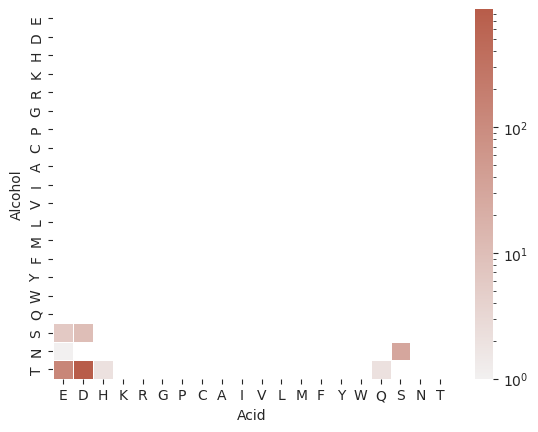

In [14]:
cmap = sns.light_palette((20, 60, 50), input='husl', as_cmap=True)
sns.set_style(style='ticks')
sns.axes_style({'font.sans-serif': 'Arial'})

heatmap = sns.heatmap(
    heatmap_orderedAA,
    norm=LogNorm(),
    linecolor='white',
    linewidths=0.5,
    cmap=cmap
    )

heatmap.set(xlabel="Acid", ylabel="Alcohol")
